In [1]:
import json
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [2]:
route_df = pd.read_csv('courier_project/data/route_dataset.csv')
route_df.head(4)

,route_id,station_code,date,departure_time_utc,route_score,total_travel_duration,total_service_time_duration,ERD_seconds,ERD_hours,num_stops_x,num_stops_y,num_stops,total_packages,packages_per_stop,avg_service_time,capacity_m3
0,RouteID_00143bdd-0a6b-49ec-bb35-36593d303e77,DLA3,2018-07-27,16:02:10,High,7754.1,12940.9,20695.0,5.748611,119,119,119,276,2.319328,46.887319,3.313071
1,RouteID_0016bc70-cb8d-48b0-aa55-8ee50bdcdb59,DSE4,2018-07-28,15:44:41,High,6647.8,18623.8,25271.6,7.019889,106,106,106,199,1.877358,93.586935,4.247527
2,RouteID_001948e9-4675-486d-9ec5-912fd8e0770f,DSE5,2018-08-18,15:32:04,High,9897.4,18951.1,28848.5,8.013472,128,128,128,212,1.656250,89.391981,4.247527
3,RouteID_001b4ee3-c4f2-467f-932b-c85524d1021f,DLA9,2018-08-15,15:09:38,High,9491.5,15476.3,24967.8,6.935500,142,142,142,241,1.697183,64.217012,3.313071


In [3]:
route_df = route_df.drop(columns=['station_code', 'ERD_seconds', 'num_stops_x', 'num_stops_y'])
route_df.head(4)

,route_id,date,departure_time_utc,route_score,total_travel_duration,total_service_time_duration,ERD_hours,num_stops,total_packages,packages_per_stop,avg_service_time,capacity_m3
0,RouteID_00143bdd-0a6b-49ec-bb35-36593d303e77,2018-07-27,16:02:10,High,7754.1,12940.9,5.748611,119,276,2.319328,46.887319,3.313071
1,RouteID_0016bc70-cb8d-48b0-aa55-8ee50bdcdb59,2018-07-28,15:44:41,High,6647.8,18623.8,7.019889,106,199,1.877358,93.586935,4.247527
2,RouteID_001948e9-4675-486d-9ec5-912fd8e0770f,2018-08-18,15:32:04,High,9897.4,18951.1,8.013472,128,212,1.656250,89.391981,4.247527
3,RouteID_001b4ee3-c4f2-467f-932b-c85524d1021f,2018-08-15,15:09:38,High,9491.5,15476.3,6.935500,142,241,1.697183,64.217012,3.313071


In [4]:
X = route_df.drop(columns = ['route_id', 'date','total_travel_duration',
                             'ERD_hours', 'avg_service_time',
                            'packages_per_stop'])
y = route_df['ERD_hours']
X.head(4)

,departure_time_utc,route_score,total_service_time_duration,num_stops,total_packages,capacity_m3
0,16:02:10,High,12940.9,119,276,3.313071
1,15:44:41,High,18623.8,106,199,4.247527
2,15:32:04,High,18951.1,128,212,4.247527
3,15:09:38,High,15476.3,142,241,3.313071


In [5]:
X['departure_time_utc'] = pd.to_datetime(X['departure_time_utc'], format='%H:%M:%S')
X['departure_hour'] = X['departure_time_utc'].dt.hour
X.drop(columns=['departure_time_utc'], inplace=True)
X

,route_score,total_service_time_duration,num_stops,total_packages,capacity_m3,departure_hour
0,High,12940.9,119,276,3.313071,16
1,High,18623.8,106,199,4.247527,15
2,High,18951.1,128,212,4.247527,15
3,High,15476.3,142,241,3.313071,15
4,High,14729.7,155,219,3.313071,14
...,...,...,...,...,...,...
6107,Medium,17864.7,83,159,4.247527,13
6108,Medium,14035.4,149,206,3.313071,14
6109,High,15198.6,190,269,3.313071,14
6110,High,16570.9,75,206,4.247527,15


In [6]:
X = pd.get_dummies(X, columns=['route_score'], drop_first=True)

X['time_zone'] = pd.cut(
    X['departure_hour'],
    bins=[10, 12, 15, 17, 19],
    labels=['late_morning', 'noon', 'afternoon', 'late_afternoon'],
    right=False)

X['time_zone'].value_counts()

time_zone
noon              2911
afternoon         2896
late_morning       203
late_afternoon     102
Name: count, dtype: int64

In [7]:
X.head(4)

,total_service_time_duration,num_stops,total_packages,capacity_m3,departure_hour,route_score_Low,route_score_Medium,time_zone
0,12940.9,119,276,3.313071,16,False,False,afternoon
1,18623.8,106,199,4.247527,15,False,False,afternoon
2,18951.1,128,212,4.247527,15,False,False,afternoon
3,15476.3,142,241,3.313071,15,False,False,afternoon


In [8]:
X = pd.get_dummies(X, columns=['time_zone'], drop_first=True)
X.drop(columns=['departure_hour'], inplace=True)
X.head(4)

,total_service_time_duration,num_stops,total_packages,capacity_m3,route_score_Low,route_score_Medium,time_zone_noon,time_zone_afternoon,time_zone_late_afternoon
0,12940.9,119,276,3.313071,False,False,False,True,False
1,18623.8,106,199,4.247527,False,False,False,True,False
2,18951.1,128,212,4.247527,False,False,False,True,False
3,15476.3,142,241,3.313071,False,False,False,True,False


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = LinearRegression()

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'MAE: {mae:.3f} hours ({mae*60:.1f} minutes)')
print(f'RMSE: {rmse:.3f} hours ({rmse*60:.1f} minutes)')
print(f'R2: {r2:.3f}')


MAE: 0.311 hours (18.7 minutes)
RMSE: 0.396 hours (23.8 minutes)
R2: 0.748


In [10]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print(f'RF MAE: {rf_mae:.3f} hours ({rf_mae*60:.1f} minutes)')
print(f'RF RMSE: {rf_rmse:.3f} hours ({rf_rmse*60:.1f} minutes)')
print(f'RF R2: {rf_r2:.3f}')

RF MAE: 0.323 hours (19.4 minutes)
RF RMSE: 0.412 hours (24.7 minutes)
RF R2: 0.727


In [11]:
importance = rf.feature_importances_

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': importance
}).sort_values('importance', ascending=False)

feature_importance

,feature,importance
0,total_service_time_duration,0.542527
1,num_stops,0.284939
2,total_packages,0.110665
3,capacity_m3,0.021287
5,route_score_Medium,0.015876
7,time_zone_afternoon,0.012884
6,time_zone_noon,0.008614
8,time_zone_late_afternoon,0.001622
4,route_score_Low,0.001586


In [12]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)

gb_mae = mean_absolute_error(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_r2 = r2_score(y_test, gb_pred)

print(f'GB MAE: {gb_mae:.3f} hours ({gb_mae*60:.1f} minutes)')
print(f'GB RMSE: {gb_rmse:.3f} hours ({gb_rmse*60:.1f} minutes)')
print(f'GB R2: {gb_r2:.3f}')

GB MAE: 0.311 hours (18.6 minutes)
GB RMSE: 0.396 hours (23.8 minutes)
GB R2: 0.748


In [13]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# XGBoost model
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)


xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = r2_score(y_test, xgb_pred)

print(f'XGBoost MAE: {xgb_mae:.3f} hours ({xgb_mae*60:.1f} minutes)')
print(f'XGBoost RMSE: {xgb_rmse:.3f} hours ({xgb_rmse*60:.1f} minutes)')
print(f'XGBoost R2: {xgb_r2:.3f}')


XGBoost MAE: 0.310 hours (18.6 minutes)
XGBoost RMSE: 0.394 hours (23.7 minutes)
XGBoost R2: 0.750


In [14]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'Gradient Boosting',
        'XGBoost'
    ],
    'MAE_minutes': [
        mae * 60,
        rf_mae * 60,
        gb_mae * 60,
        xgb_mae * 60
    ],
    'RMSE_minutes': [
        rmse * 60,
        rf_rmse * 60,
        gb_rmse * 60,
        xgb_rmse * 60
    ],
    'R2': [
        r2,
        rf_r2,
        gb_r2,
        xgb_r2
    ]
})

results = results.sort_values(by='MAE_minutes', ascending=True)
results


,Model,MAE_minutes,RMSE_minutes,R2
3,XGBoost,18.580666,23.651736,0.750290
2,Gradient Boosting,18.645770,23.774866,0.747683
0,Linear Regression,18.670457,23.751686,0.748175
1,Random Forest,19.362741,24.729052,0.727024


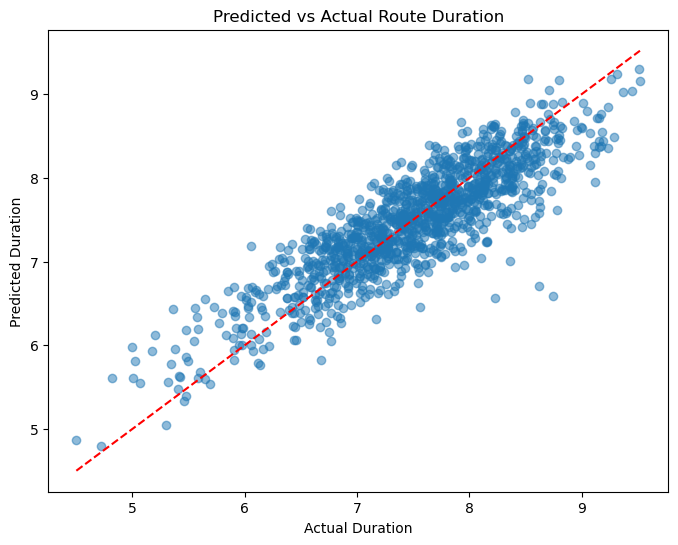

In [15]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, xgb_pred, alpha=0.5)

min_val = min(y_test.min(), xgb_pred.min())
max_val = max(y_test.max(), xgb_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')

plt.xlabel('Actual Duration')
plt.ylabel('Predicted Duration')
plt.title('Predicted vs Actual Route Duration')

plt.show()

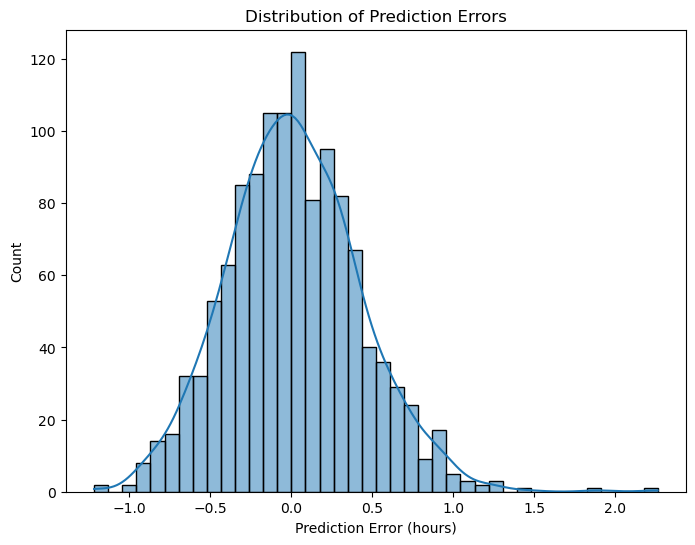

In [16]:
residuals = y_test - rf_pred


plt.figure(figsize=(8,6))
sns.histplot(residuals, bins=40, kde=True)
plt.title('Distribution of Prediction Errors')
plt.xlabel('Prediction Error (hours)')
plt.show()

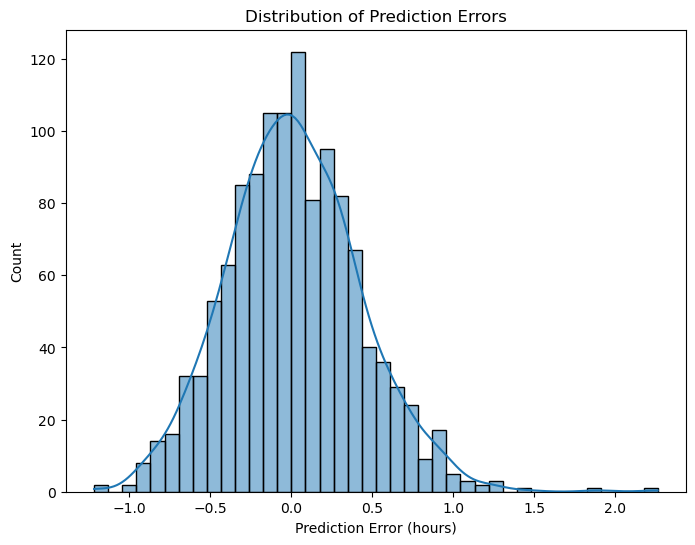

In [17]:
plt.figure(figsize=(8,6))
sns.histplot(residuals, bins=40, kde=True)
plt.title('Distribution of Prediction Errors')
plt.xlabel('Prediction Error (hours)')
plt.show()

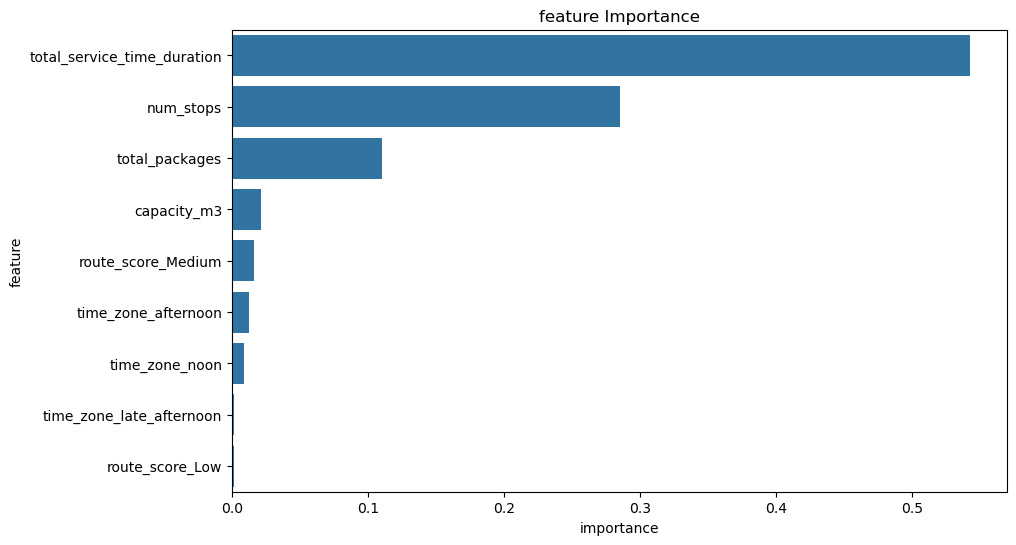

In [18]:
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=importance, x='importance', y='feature')
plt.title('feature Importance')
plt.show()

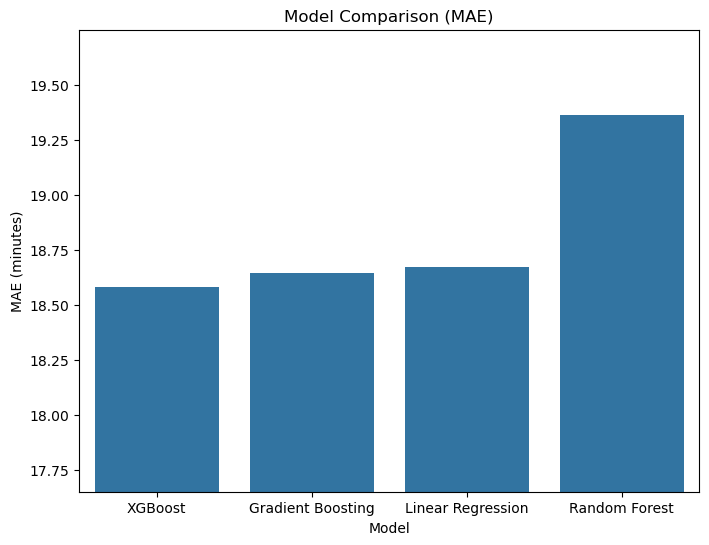

In [19]:
plt.figure(figsize=(8,6))

sns.barplot(data=results, x='Model', y='MAE_minutes')

plt.title('Model Comparison (MAE)')
plt.ylabel('MAE (minutes)')
plt.xlabel('Model')

plt.ylim(results['MAE_minutes'].min()*0.95, results['MAE_minutes'].max()*1.02)
plt.show()